<a href="https://colab.research.google.com/github/Andres200644/DataScience2_AndresHeredia_pf/blob/main/dts_2_proyecto_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Abstracto

En la industria del comercio electrónico, comprender el comportamiento del cliente es clave para aumentar ventas y optimizar estrategias de marketing.

En este proyecto se analizan datos de una tienda con el objetivo de predecir [VARIABLE OBJETIVO], utilizando modelos de Machine Learning.

Este análisis está dirigido a:
- Equipos de marketing
- Analistas de datos
- Dueños de e-commerce

El valor principal radica en mejorar la toma de decisiones basada en datos y automatizar predicciones clave.

# Problema

¿Podemos predecir si un cliente realizará una compra?

Esto se modela como un problema de clasificación binaria:
- 1 = Compra
- 0 = No compra

¿Podemos predecir el monto de compra de un cliente?

In [3]:
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Subir archivo
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# Detectar tipo de archivo automáticamente
if file_name.endswith('.csv'):
    df = pd.read_csv(file_name)
elif file_name.endswith('.xlsx'):
    df = pd.read_excel(file_name)
else:
    raise ValueError("Formato no soportado")

# Vista inicial
df.head()

Saving tienda_dataset.xlsx to tienda_dataset (1).xlsx


,user_id,edad,genero,visitas_sitio,tiempo_en_sitio,minutos,productos_vistos,carrito_agregado,descuento_aplicado,compra
0,1,23,Masculino,5,12,8,3,1,0,1
1,2,35,Femenino,2,5,2,1,0,0,0
2,3,29,Femenino,8,20,12,6,1,1,1
3,4,41,Masculino,1,2,1,0,0,0,0
4,5,22,Femenino,10,25,15,8,1,1,1


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   user_id             20 non-null     int64 
 1   edad                20 non-null     int64 
 2   genero              20 non-null     object
 3   visitas_sitio       20 non-null     int64 
 4   tiempo_en_sitio     20 non-null     int64 
 5   minutos             20 non-null     int64 
 6   productos_vistos    20 non-null     int64 
 7   carrito_agregado    20 non-null     int64 
 8   descuento_aplicado  20 non-null     int64 
 9   compra              20 non-null     int64 
dtypes: int64(9), object(1)
memory usage: 1.7+ KB


,user_id,edad,visitas_sitio,tiempo_en_sitio,minutos,productos_vistos,carrito_agregado,descuento_aplicado,compra
count,20.00000,20.000000,20.000000,20.000000,20.000000,20.0000,20.000000,20.00000,20.000000
mean,10.50000,31.450000,5.250000,13.150000,7.750000,3.7000,0.500000,0.35000,0.500000
std,5.91608,7.126489,3.176807,7.909189,5.066661,2.7549,0.512989,0.48936,0.512989
min,1.00000,21.000000,1.000000,2.000000,1.000000,0.0000,0.000000,0.00000,0.000000
25%,5.75000,25.750000,2.750000,6.750000,3.750000,1.7500,0.000000,0.00000,0.000000
50%,10.50000,30.500000,4.500000,11.000000,7.000000,3.0000,0.500000,0.00000,0.500000
75%,15.25000,36.500000,8.000000,20.250000,12.250000,6.0000,1.000000,1.00000,1.000000
max,20.00000,45.000000,11.000000,27.000000,16.000000,9.0000,1.000000,1.00000,1.000000


In [5]:
df.isnull().sum()

,0
user_id,0
edad,0
genero,0
visitas_sitio,0
tiempo_en_sitio,0
minutos,0
productos_vistos,0
carrito_agregado,0
descuento_aplicado,0
compra,0


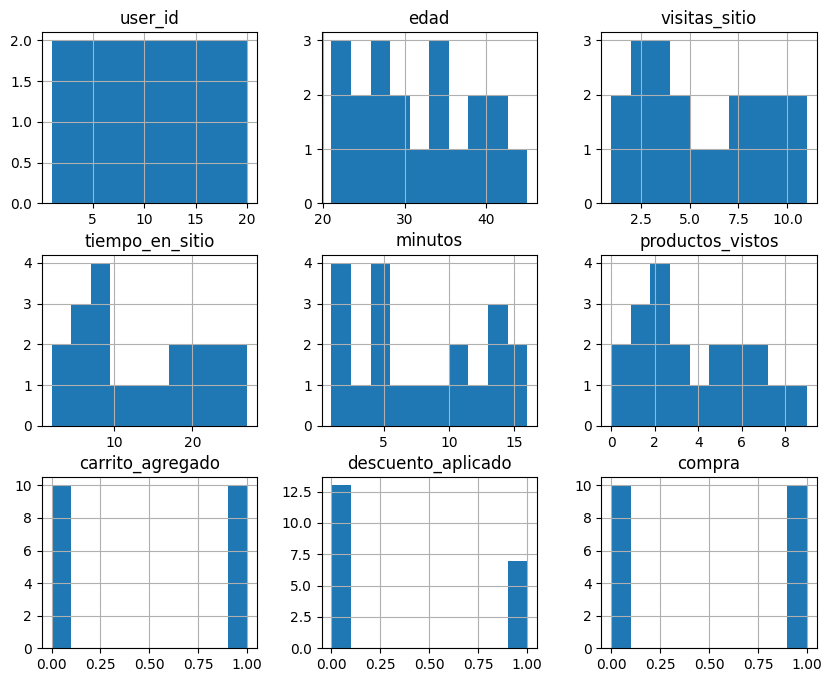

In [6]:
df.hist(figsize=(10,8))
plt.show()

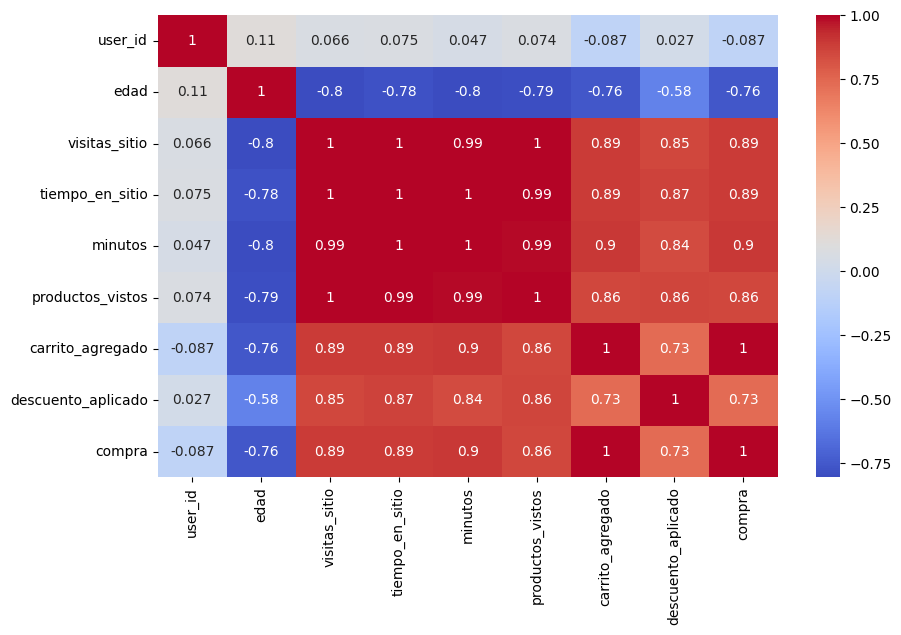

In [7]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [9]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Convertir genero a numérico
le = LabelEncoder()
df['genero'] = le.fit_transform(df['genero'])

# Separar variables
X = df.drop(['compra', 'user_id'], axis=1)
y = df['compra']

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy RF:", accuracy_score(y_test, y_pred_rf))

Accuracy RF: 0.75


In [12]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("Accuracy XGB:", accuracy_score(y_test, y_pred_xgb))

Accuracy XGB: 0.5


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:12:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [13]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X_scaled, y, cv=5)
print("CV Score:", scores.mean())

CV Score: 0.95


In [14]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)

Mejores parámetros: {'max_depth': 5, 'n_estimators': 100}


In [15]:
from sklearn.metrics import classification_report, confusion_matrix

print("Random Forest")
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

Random Forest
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       0.00      0.00      0.00         1

    accuracy                           0.75         4
   macro avg       0.38      0.50      0.43         4
weighted avg       0.56      0.75      0.64         4

[[3 0]
 [1 0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [18]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score

ensemble = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('xgb', xgb)
    ],
    voting='soft'  # usa probabilidades
)

ensemble.fit(X_train, y_train)
y_pred_ens = ensemble.predict(X_test)

print("Accuracy Ensemble:", accuracy_score(y_test, y_pred_ens))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:14:24] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy Ensemble: 0.75


In [17]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('xgb', xgb)
    ],
    voting='soft'
)

ensemble.fit(X_train, y_train)
y_pred_ens = ensemble.predict(X_test)

print("Accuracy Ensemble:", accuracy_score(y_test, y_pred_ens))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:13:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy Ensemble: 0.5
